# 04 — Is the Sharpe real, or is it luck?

A backtest Sharpe is an estimate from noisy, finite data, and if it is the *best of many* tried
strategies it is biased upward even with zero skill. This notebook puts numbers on both effects: a
bootstrap confidence interval and the **Probabilistic Sharpe Ratio** for the sampling noise, and the
**Deflated Sharpe Ratio** for the search. (The companion note *Significance and Multiple Testing* has the
full derivations; here I show them at work.)

In [1]:
import os, sys
from itertools import combinations
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import config, data, backtest, significance as sig

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, INK = "#0072B2", "#E69F00", "#1B1F24"
semis = data.align_prices(pd.read_csv("../data/semis.csv", index_col=0, parse_dates=True))
allp = data.align_prices(pd.read_csv("../data/pairs.csv", index_col=0, parse_dates=True))
pairs = allp[[t for t in config.PAIRS_UNIVERSE if t in allp.columns]]

def wf(px, a, b, entry=1.5, cost=0.0005):
    return backtest.walk_forward(np.log(px[a]), np.log(px[b]), train=252, step=63, entry=entry, exit=0.0, cost=cost)

mav = wf(pairs, "MA", "V")["pnl"]

## The Sharpe has error bars

The estimate $\widehat{SR}$ has a standard error that shrinks with sample size and widens with skew and
fat tails. A model-free way to see it: resample the PnL in blocks (to keep short-run autocorrelation),
recompute the annualized Sharpe on each resample, and read off the 2.5th–97.5th percentiles. If that
interval clears zero, the Sharpe is distinguishable from zero in-sample.

MA/V Sharpe = 1.26   95% CI = [0.78, 1.79]   P(SR<=0) = 0.00


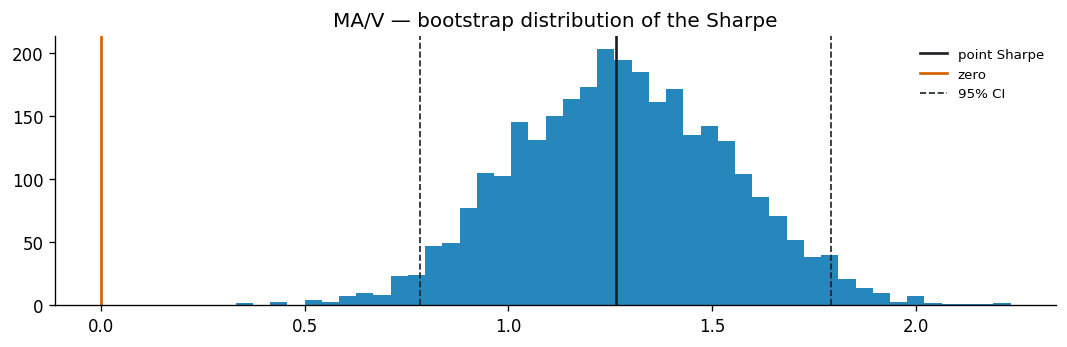

In [2]:
ci = sig.bootstrap_sharpe_ci(mav, n_boot=3000, block=5, seed=0)
print(f"MA/V Sharpe = {ci['sharpe']:.2f}   95% CI = [{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]   P(SR<=0) = {ci['p_value']:.2f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(ci["boot"], bins=45, color=BLUE, alpha=0.85)
ax.axvline(ci["sharpe"], color=INK, lw=1.6, label="point Sharpe")
ax.axvline(0, color="#D55E00", lw=1.6, label="zero")
ax.axvline(ci["ci_low"], color=INK, ls="--", lw=1); ax.axvline(ci["ci_high"], color=INK, ls="--", lw=1, label="95% CI")
ax.legend(frameon=False, fontsize=8); ax.set_title("MA/V — bootstrap distribution of the Sharpe")
plt.tight_layout(); plt.show()

## PSR — the probability the true Sharpe beats zero

The Probabilistic Sharpe Ratio standardises $\widehat{SR}$ against a benchmark using its skew/kurtosis-aware
standard error, and returns a probability:
$$\mathrm{PSR}=\Phi\!\left(\frac{(\widehat{SR}-SR^{*})\sqrt{n-1}}{\sqrt{1-\gamma_3\widehat{SR}+\tfrac{\gamma_4-1}{4}\widehat{SR}^{2}}}\right).$$
Above $0.95$ before I would believe a curve; near $0.5$ it could easily be nothing.

In [3]:
print(f"MA/V PSR (vs 0) = {sig.probabilistic_sharpe_ratio(mav):.3f}")

MA/V PSR (vs 0) = 1.000


## The Deflated Sharpe — paying for the search

Now the harder question: what if I had searched many pairs and kept the best? A skill-less search of $N$
strategies is *expected* to produce a maximum Sharpe well above zero, and the Deflated Sharpe is the PSR
measured against that luck benchmark $SR^{*}=\mathbb{E}[\max_N \widehat{SR}\mid\text{no skill}]$. The
contrast below is the whole point.

In [4]:
# Blind search: every semiconductor pair, keep the best, then deflate for having searched them all.
sr_semis, best = [], (-9, None, None)
for a, b in combinations(semis.columns, 2):
    r = backtest.walk_forward(np.log(semis[a]), np.log(semis[b]), train=252, step=63, entry=2.0, exit=0.0, cost=0.001)
    s = sig._per_period_sharpe(r["pnl"]); sr_semis.append(s)
    if s > best[0]: best = (s, f"{a}~{b}", r["pnl"])
dsr_semis = sig.deflated_sharpe_ratio(best[2], sr_trials=np.array(sr_semis))
print(f"Semis blind best-of-{len(sr_semis)}: {best[1]}, Sharpe {best[0]*np.sqrt(252):.2f}")
print(f"  luck benchmark = {dsr_semis['sr_star']*np.sqrt(252):.2f} ann  ->  Deflated Sharpe = {dsr_semis['dsr']:.2f}  (chance)")

# Pre-declared economic pairs: MA/V was chosen a priori, so it only pays for a short list.
econ = [("MA","V"),("KO","PEP"),("XOM","CVX"),("HD","LOW"),("GS","MS"),("WMT","TGT"),("GLD","IAU")]
sr_econ = np.array([sig._per_period_sharpe(wf(pairs, a, b)["pnl"]) for a, b in econ])
dsr_mav = sig.deflated_sharpe_ratio(mav, sr_trials=sr_econ)
print(f"\nMA/V, deflated vs the {len(econ)} pre-declared pairs -> Deflated Sharpe = {dsr_mav['dsr']:.2f}  (a real edge)")

Semis blind best-of-210: KLAC~TER, Sharpe 0.54
  luck benchmark = 0.78 ann  ->  Deflated Sharpe = 0.21  (chance)



MA/V, deflated vs the 7 pre-declared pairs -> Deflated Sharpe = 0.97  (a real edge)


Same machinery, opposite verdicts. The blind best-of-210 sits right at the luck bar and deflates to a
coin flip; MA/V, chosen for an economic reason rather than mined from the screen, survives at ≈0.97. The
difference is not the strategy — it is how many things were tried before settling on it.